<a href="https://colab.research.google.com/github/aabyyaann/scikit-learn-Cookbook/blob/main/Chapter7_Support_Vector_Machines_and_Kernel_Methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 7 - Support Vector Machines and Kernel Methods

Notebook ini merangkum dan mereproduksi konsep utama pada **Chapter 7: Support Vector Machines and Kernel Methods** dari buku **scikit-learn Cookbook**.

Pada chapter ini, fokus pembahasan adalah bagaimana **Support Vector Machine (SVM)** digunakan untuk klasifikasi, bagaimana **kernel trick** membantu menangani data non-linear, bagaimana melakukan **tuning hyperparameter**, bagaimana SVM bekerja pada **high-dimensional data**, dan bagaimana mengevaluasi performa model SVM secara sistematis.

## Topik utama chapter ini
1. Pengenalan Support Vector Machine (SVM)
2. Kernel functions dan penerapannya
3. Tuning hyperparameter SVM
4. SVM pada data berdimensi tinggi
5. Evaluasi model SVM
6. Latihan praktis klasifikasi dengan SVM

Chapter ini menekankan bahwa SVM adalah algoritma supervised learning yang sangat kuat untuk klasifikasi, terutama ketika data memiliki batas pemisah yang jelas atau ketika kita ingin menggunakan transformasi kernel untuk memisahkan data yang tidak linear.

## 1. Import Library

Pada bagian awal, kita mengimpor library yang dibutuhkan untuk:
- manipulasi data
- visualisasi
- membuat dataset sintetis
- training model SVM
- tuning hyperparameter
- evaluasi model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_breast_cancer, make_moons, make_classification
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

sns.set_style("whitegrid")
np.random.seed(42)

print("Library untuk Chapter 7 berhasil dimuat.")

Library untuk Chapter 7 berhasil dimuat.


## 2. Konsep Dasar SVM

Support Vector Machine (SVM) adalah algoritma supervised learning yang digunakan untuk klasifikasi maupun regresi, walaupun paling sering digunakan untuk klasifikasi.

Ide utama SVM adalah mencari **hyperplane terbaik** yang memisahkan dua kelas. Hyperplane terbaik dipilih dengan memaksimalkan **margin**, yaitu jarak antara batas keputusan dengan titik data terdekat dari masing-masing kelas.

Titik data yang paling dekat dengan hyperplane disebut **support vectors**. Titik-titik inilah yang paling berpengaruh dalam menentukan posisi batas keputusan model.

Secara intuitif:
- margin besar → model cenderung lebih stabil
- support vector → titik paling penting dalam pembentukan batas
- parameter seperti **C** dan **kernel** sangat memengaruhi bentuk model

## 3. Dataset Pertama: Iris

Untuk pengenalan awal SVM, kita gunakan dataset **Iris**.  
Agar visualisasi lebih mudah, kita ambil **dua fitur pertama** dan hanya gunakan **dua kelas** terlebih dahulu.

In [2]:
iris = load_iris()

X_iris = iris.data[:, :2]   # dua fitur pertama agar mudah divisualisasikan
y_iris = iris.target

# Ambil hanya dua kelas: setosa dan versicolor
mask = y_iris < 2
X_binary = X_iris[mask]
y_binary = y_iris[mask]

print("Shape X:", X_binary.shape)
print("Distribusi kelas:", np.bincount(y_binary))
print("Nama kelas:", iris.target_names[:2])

Shape X: (100, 2)
Distribusi kelas: [50 50]
Nama kelas: ['setosa' 'versicolor']


In [3]:
df_iris = pd.DataFrame(X_binary, columns=iris.feature_names[:2])
df_iris["target"] = y_binary
df_iris["species"] = df_iris["target"].map({0: iris.target_names[0], 1: iris.target_names[1]})

df_iris.head()

,sepal length (cm),sepal width (cm),target,species
0,5.1,3.5,0,setosa
1,4.9,3.0,0,setosa
2,4.7,3.2,0,setosa
3,4.6,3.1,0,setosa
4,5.0,3.6,0,setosa


## 4. Visualisasi Data Iris (2 kelas)

Visualisasi ini membantu melihat apakah dua kelas memiliki pola pemisahan yang cukup jelas pada dua fitur pertama.

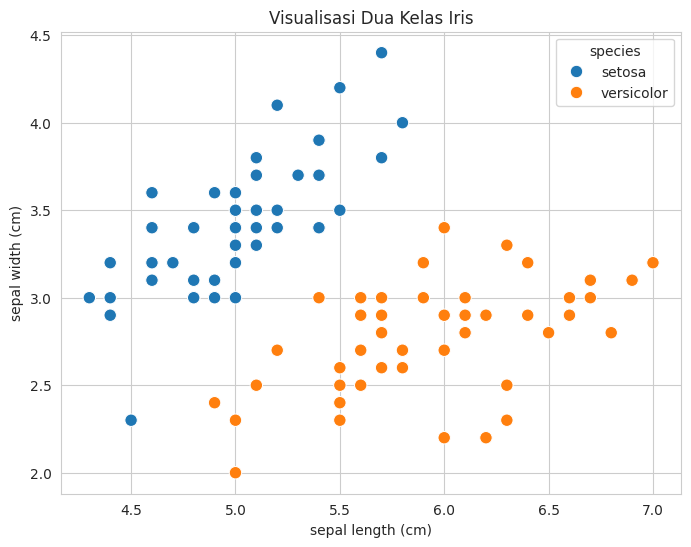

In [4]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_iris,
    x=iris.feature_names[0],
    y=iris.feature_names[1],
    hue="species",
    s=80
)
plt.title("Visualisasi Dua Kelas Iris")
plt.show()

## 5. Training SVM Linear Sederhana

Kita mulai dari **SVM linear** menggunakan `SVC(kernel='linear')`.

Karena SVM sensitif terhadap skala fitur, kita akan menggunakan **StandardScaler** sebelum model.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_binary, y_binary, test_size=0.25, random_state=42, stratify=y_binary
)

svm_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1.0))
])

svm_linear.fit(X_train, y_train)
y_pred = svm_linear.predict(X_test)

print("Accuracy train:", round(svm_linear.score(X_train, y_train), 4))
print("Accuracy test :", round(accuracy_score(y_test, y_pred), 4))

Accuracy train: 1.0
Accuracy test : 0.96


In [6]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=iris.target_names[:2]))

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      0.92      0.96        13
  versicolor       0.92      1.00      0.96        12

    accuracy                           0.96        25
   macro avg       0.96      0.96      0.96        25
weighted avg       0.96      0.96      0.96        25



## 6. Confusion Matrix

Confusion matrix membantu melihat jumlah prediksi benar dan salah pada tiap kelas.

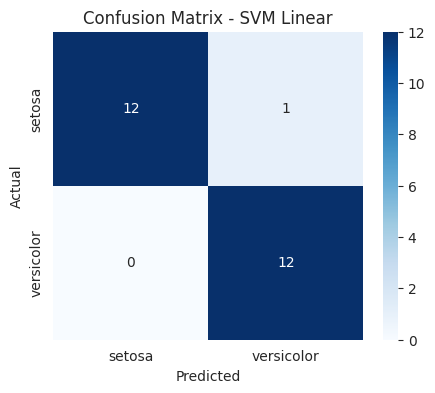

In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names[:2],
    yticklabels=iris.target_names[:2]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM Linear")
plt.show()

## 7. Visualisasi Decision Boundary SVM Linear

Agar terlihat bagaimana SVM bekerja, kita plot decision boundary dari model linear pada data dua dimensi.

In [8]:
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=70, cmap=plt.cm.coolwarm, edgecolor="k")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    plt.show()

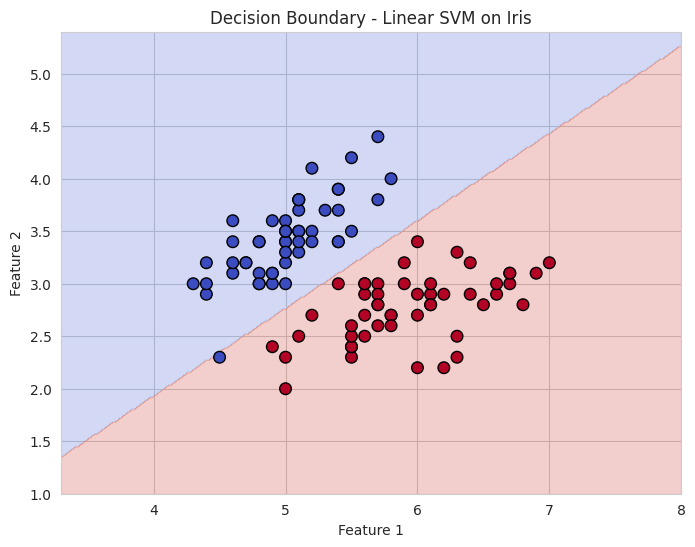

In [9]:
plot_decision_boundary(
    svm_linear,
    X_binary,
    y_binary,
    title="Decision Boundary - Linear SVM on Iris"
)

## 8. Pengaruh Hyperparameter C

Pada SVM, parameter **C** mengatur trade-off antara:
- membuat margin besar
- meminimalkan kesalahan klasifikasi pada data training

Interpretasi sederhana:
- **C kecil** → model lebih toleran terhadap kesalahan, margin cenderung lebih longgar
- **C besar** → model lebih berusaha mengklasifikasikan semua titik training dengan benar, sehingga bisa menjadi lebih kompleks

In [10]:
C_values = [0.01, 0.1, 1, 10, 100]
results_c = []

for c in C_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="linear", C=c))
    ])
    model.fit(X_train, y_train)

    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)

    results_c.append([c, train_acc, test_acc])

results_c_df = pd.DataFrame(results_c, columns=["C", "Train Accuracy", "Test Accuracy"])
results_c_df

,C,Train Accuracy,Test Accuracy
0,0.01,1.0,0.96
1,0.10,1.0,1.00
2,1.00,1.0,0.96
3,10.00,1.0,0.96
4,100.00,1.0,0.96


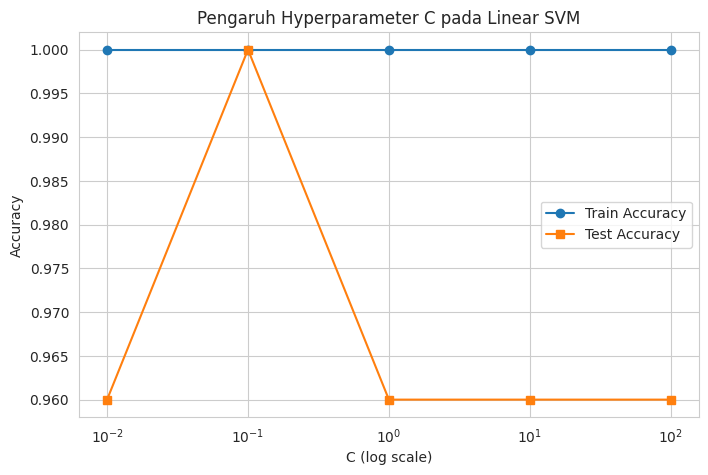

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(results_c_df["C"], results_c_df["Train Accuracy"], marker="o", label="Train Accuracy")
plt.plot(results_c_df["C"], results_c_df["Test Accuracy"], marker="s", label="Test Accuracy")
plt.xscale("log")
plt.xlabel("C (log scale)")
plt.ylabel("Accuracy")
plt.title("Pengaruh Hyperparameter C pada Linear SVM")
plt.legend()
plt.show()

## 9. Kernel Trick

Salah satu kekuatan utama SVM adalah kemampuannya menangani data **non-linear** melalui **kernel trick**.

Kernel memungkinkan kita seolah-olah memproyeksikan data ke ruang berdimensi lebih tinggi tanpa benar-benar menghitung koordinat baru secara eksplisit.

Kernel yang umum:
- **linear**
- **rbf**
- **poly**
- **sigmoid**

Pada praktiknya, **RBF kernel** sering menjadi pilihan awal yang kuat untuk data non-linear.

## 10. Dataset Non-Linear: make_moons

Untuk menunjukkan pentingnya kernel, kita buat dataset sintetis non-linear menggunakan `make_moons`.

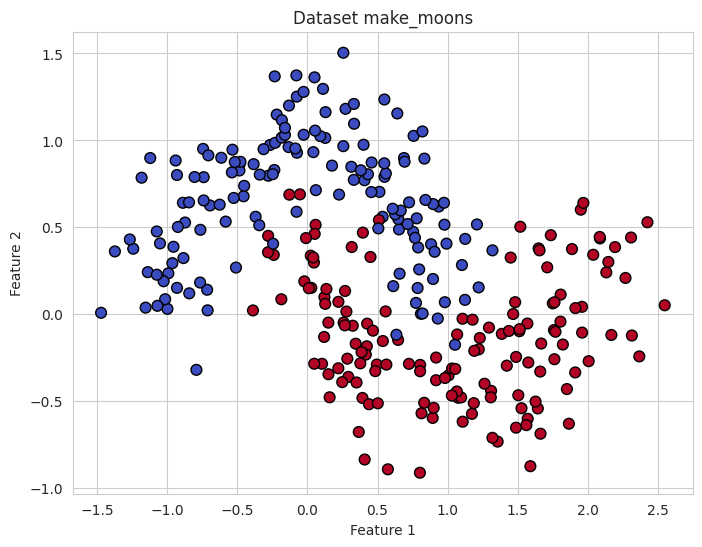

In [12]:
X_moons, y_moons = make_moons(n_samples=300, noise=0.2, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap=plt.cm.coolwarm, s=60, edgecolor="k")
plt.title("Dataset make_moons")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

## 11. Membandingkan Linear SVM vs RBF SVM

Pada data non-linear, SVM linear biasanya kesulitan membentuk batas keputusan yang baik.  
Sebaliknya, kernel **RBF** dapat membentuk boundary yang lebih fleksibel.

In [13]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_moons, y_moons, test_size=0.25, random_state=42, stratify=y_moons
)

svm_linear_moons = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1.0))
])

svm_rbf_moons = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

svm_linear_moons.fit(X_train_m, y_train_m)
svm_rbf_moons.fit(X_train_m, y_train_m)

print("Linear SVM Test Accuracy :", round(svm_linear_moons.score(X_test_m, y_test_m), 4))
print("RBF SVM Test Accuracy    :", round(svm_rbf_moons.score(X_test_m, y_test_m), 4))

Linear SVM Test Accuracy : 0.8533
RBF SVM Test Accuracy    : 0.9067


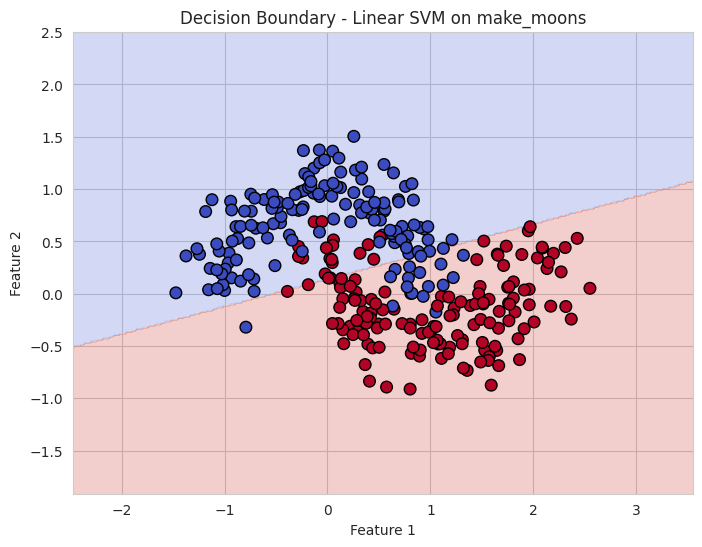

In [14]:
plot_decision_boundary(
    svm_linear_moons,
    X_moons,
    y_moons,
    title="Decision Boundary - Linear SVM on make_moons"
)

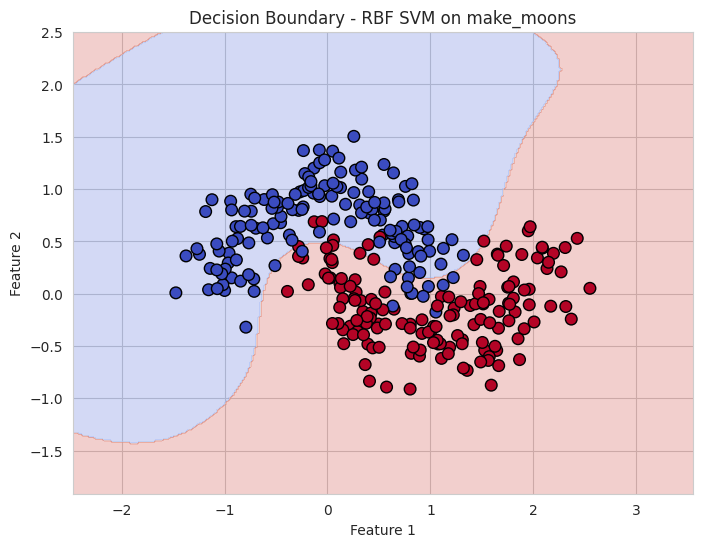

In [15]:
plot_decision_boundary(
    svm_rbf_moons,
    X_moons,
    y_moons,
    title="Decision Boundary - RBF SVM on make_moons"
)

## 12. Pengaruh Hyperparameter Gamma pada RBF Kernel

Pada kernel RBF, parameter **gamma** mengontrol seberapa jauh pengaruh satu titik data.

Secara umum:
- **gamma kecil** → boundary lebih halus / lebih sederhana
- **gamma besar** → boundary lebih detail / lebih kompleks

Jika terlalu besar, model bisa menjadi terlalu sensitif terhadap data training.

In [16]:
gamma_values = [0.01, 0.1, 1, 10]
gamma_results = []

for g in gamma_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", C=1.0, gamma=g))
    ])
    model.fit(X_train_m, y_train_m)

    train_acc = model.score(X_train_m, y_train_m)
    test_acc = model.score(X_test_m, y_test_m)

    gamma_results.append([g, train_acc, test_acc])

gamma_df = pd.DataFrame(gamma_results, columns=["gamma", "Train Accuracy", "Test Accuracy"])
gamma_df

,gamma,Train Accuracy,Test Accuracy
0,0.01,0.866667,0.813333
1,0.10,0.880000,0.840000
2,1.00,0.968889,0.960000
3,10.00,0.982222,0.946667


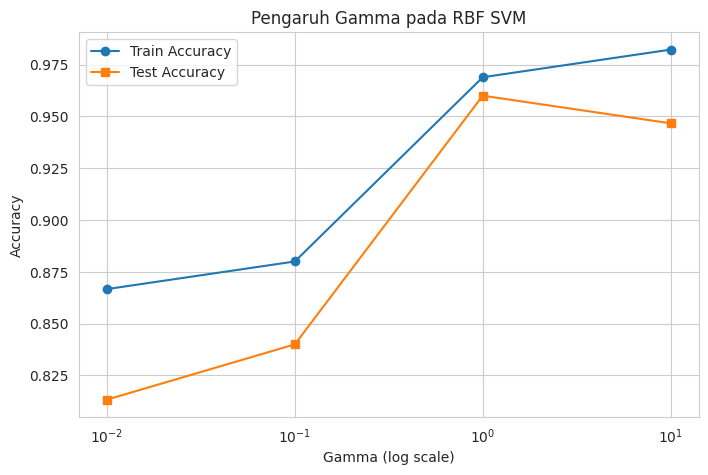

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(gamma_df["gamma"], gamma_df["Train Accuracy"], marker="o", label="Train Accuracy")
plt.plot(gamma_df["gamma"], gamma_df["Test Accuracy"], marker="s", label="Test Accuracy")
plt.xscale("log")
plt.xlabel("Gamma (log scale)")
plt.ylabel("Accuracy")
plt.title("Pengaruh Gamma pada RBF SVM")
plt.legend()
plt.show()

## 13. Tuning Hyperparameter SVM dengan GridSearchCV

Pada praktik nyata, kita tidak memilih parameter C dan gamma secara manual saja.  
Kita bisa menggunakan **GridSearchCV** untuk mencari kombinasi parameter terbaik berdasarkan cross-validation.

### Dataset untuk tuning: Breast Cancer Dataset

Dataset Breast Cancer sering dipakai untuk klasifikasi biner.  
Kita akan menggunakan dataset ini untuk melakukan tuning SVM secara lebih realistis.

In [18]:
cancer = load_breast_cancer()
X_cancer = cancer.data
y_cancer = cancer.target

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, stratify=y_cancer, random_state=42, test_size=0.25
)

print("Shape X_train:", X_train_c.shape)
print("Shape X_test :", X_test_c.shape)
print("Nama target  :", cancer.target_names)

Shape X_train: (426, 30)
Shape X_test : (143, 30)
Nama target  : ['malignant' 'benign']


In [19]:
pipe_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf"))
])

param_grid = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": [0.001, 0.01, 0.1, 1]
}

grid_svm = GridSearchCV(
    pipe_svm,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_svm.fit(X_train_c, y_train_c)

print("Best Parameters:", grid_svm.best_params_)
print("Best CV Score  :", round(grid_svm.best_score_, 4))
print("Test Score     :", round(grid_svm.score(X_test_c, y_test_c), 4))

Best Parameters: {'svm__C': 10, 'svm__gamma': 0.001}
Best CV Score  : 0.9765
Test Score     : 0.979


In [20]:
results_grid = pd.DataFrame(grid_svm.cv_results_)
results_grid = results_grid[[
    "param_svm__C",
    "param_svm__gamma",
    "mean_test_score",
    "rank_test_score"
]].sort_values("rank_test_score")

results_grid.head(10)

,param_svm__C,param_svm__gamma,mean_test_score,rank_test_score
8,10.0,0.001,0.976525,1
5,1.0,0.010,0.971819,2
12,100.0,0.001,0.969466,3
13,100.0,0.010,0.962435,4
9,10.0,0.010,0.962408,5
4,1.0,0.001,0.945992,6
6,1.0,0.100,0.945964,7
14,100.0,0.100,0.943694,8
1,0.1,0.010,0.943639,9
10,10.0,0.100,0.941341,10


## 14. Visualisasi hasil tuning parameter

Kita buat heatmap agar lebih mudah melihat kombinasi **C** dan **gamma** yang menghasilkan akurasi terbaik.

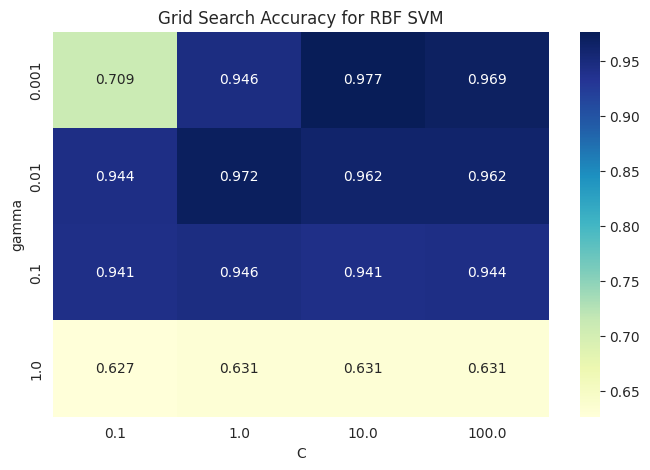

In [21]:
pivot_table = results_grid.pivot_table(
    values="mean_test_score",
    index="param_svm__gamma",
    columns="param_svm__C"
)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Grid Search Accuracy for RBF SVM")
plt.xlabel("C")
plt.ylabel("gamma")
plt.show()

## 15. SVM pada Data Berdimensi Tinggi

SVM sering digunakan pada data berdimensi tinggi, misalnya:
- data teks hasil vectorization
- data genomik
- data dengan jumlah fitur sangat besar

Untuk mensimulasikan kondisi ini, kita akan membuat dataset sintetis dengan jumlah fitur yang cukup banyak.

In [22]:
X_hd, y_hd = make_classification(
    n_samples=1000,
    n_features=100,
    n_informative=20,
    n_redundant=10,
    n_classes=2,
    random_state=42
)

X_train_hd, X_test_hd, y_train_hd, y_test_hd = train_test_split(
    X_hd, y_hd, test_size=0.25, random_state=42, stratify=y_hd
)

print("Train shape:", X_train_hd.shape)
print("Test shape :", X_test_hd.shape)

Train shape: (750, 100)
Test shape : (250, 100)


### LinearSVC vs RBF SVC

Pada data berdimensi tinggi:
- **LinearSVC** sering lebih cepat dan efisien
- **SVC dengan kernel RBF** bisa lebih fleksibel, tetapi komputasinya biasanya lebih berat

In [23]:
linear_svc_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(max_iter=10000, random_state=42))
])

rbf_svc_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

linear_svc_model.fit(X_train_hd, y_train_hd)
rbf_svc_model.fit(X_train_hd, y_train_hd)

linear_acc = linear_svc_model.score(X_test_hd, y_test_hd)
rbf_acc = rbf_svc_model.score(X_test_hd, y_test_hd)

print("LinearSVC Test Accuracy:", round(linear_acc, 4))
print("RBF SVC Test Accuracy  :", round(rbf_acc, 4))

LinearSVC Test Accuracy: 0.76
RBF SVC Test Accuracy  : 0.832


In [24]:
comparison_hd = pd.DataFrame({
    "Model": ["LinearSVC", "RBF SVC"],
    "Test Accuracy": [linear_acc, rbf_acc]
})

comparison_hd

,Model,Test Accuracy
0,LinearSVC,0.760
1,RBF SVC,0.832


## 16. Evaluasi Model SVM secara Lengkap

Sekarang kita evaluasi model terbaik hasil tuning pada dataset Breast Cancer menggunakan:
- accuracy
- classification report
- confusion matrix
- ROC curve
- ROC AUC

In [25]:
best_svm = grid_svm.best_estimator_
y_pred_c = best_svm.predict(X_test_c)
y_score_c = best_svm.decision_function(X_test_c)

print("Accuracy:", round(accuracy_score(y_test_c, y_pred_c), 4))
print("\nClassification Report:\n")
print(classification_report(y_test_c, y_pred_c, target_names=cancer.target_names))

Accuracy: 0.979

Classification Report:

              precision    recall  f1-score   support

   malignant       0.98      0.96      0.97        53
      benign       0.98      0.99      0.98        90

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



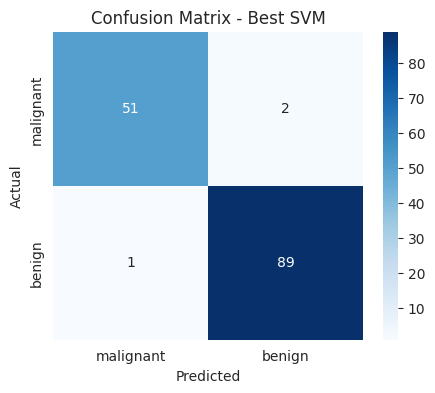

In [26]:
cm_cancer = confusion_matrix(y_test_c, y_pred_c)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_cancer,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=cancer.target_names,
    yticklabels=cancer.target_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Best SVM")
plt.show()

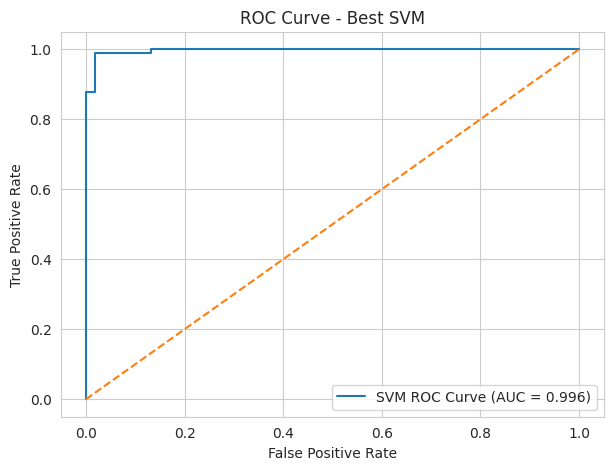

ROC AUC: 0.9964


In [27]:
roc_auc = roc_auc_score(y_test_c, y_score_c)
fpr, tpr, thresholds = roc_curve(y_test_c, y_score_c)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"SVM ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Best SVM")
plt.legend()
plt.show()

print("ROC AUC:", round(roc_auc, 4))

## 17. Cross-Validation untuk Mengukur Stabilitas Model

Akurasi test split tunggal kadang belum cukup.  
Karena itu kita gunakan **cross-validation** untuk melihat kestabilan performa model pada beberapa fold data.

In [28]:
cv_scores = cross_val_score(best_svm, X_cancer, y_cancer, cv=5, scoring="accuracy")

print("Cross-validation scores:", np.round(cv_scores, 4))
print("Mean CV accuracy       :", round(cv_scores.mean(), 4))
print("Std CV accuracy        :", round(cv_scores.std(), 4))

Cross-validation scores: [0.9561 0.9737 0.9737 0.9649 0.9823]
Mean CV accuracy       : 0.9701
Std CV accuracy        : 0.0089


## 18. Practical Exercise 1 - Simple SVM Classifier

Bagian ini meniru pola latihan di akhir chapter: membangun classifier SVM sederhana menggunakan dataset Iris.

In [29]:
X_ex1 = iris.data
y_ex1 = iris.target

X_train_ex1, X_test_ex1, y_train_ex1, y_test_ex1 = train_test_split(
    X_ex1, y_ex1, test_size=0.25, random_state=42, stratify=y_ex1
)

exercise_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=1.0, gamma="scale"))
])

exercise_model.fit(X_train_ex1, y_train_ex1)
y_pred_ex1 = exercise_model.predict(X_test_ex1)

print("Exercise 1 - Accuracy:", round(accuracy_score(y_test_ex1, y_pred_ex1), 4))
print(classification_report(y_test_ex1, y_pred_ex1, target_names=iris.target_names))

Exercise 1 - Accuracy: 0.9474
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.92      0.92      0.92        13
   virginica       0.92      0.92      0.92        13

    accuracy                           0.95        38
   macro avg       0.95      0.95      0.95        38
weighted avg       0.95      0.95      0.95        38



## 19. Practical Exercise 2 - Tuning SVM dengan Grid Search

Sekarang kita lakukan tuning SVM pada Breast Cancer dataset dengan grid search, sesuai semangat latihan pada chapter ini.

In [30]:
param_grid_small = {
    "svm__C": [0.1, 1, 10],
    "svm__gamma": [0.001, 0.01, 0.1]
}

grid_small = GridSearchCV(
    Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf"))
    ]),
    param_grid_small,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_small.fit(X_train_c, y_train_c)

print("Best parameters:", grid_small.best_params_)
print("Best CV score  :", round(grid_small.best_score_, 4))
print("Test score     :", round(grid_small.score(X_test_c, y_test_c), 4))

Best parameters: {'svm__C': 10, 'svm__gamma': 0.001}
Best CV score  : 0.9765
Test score     : 0.979


## 20. Practical Exercise 3 - Visualisasi Decision Boundary pada Data Non-Linear

Kita kembali ke dataset `make_moons` untuk menunjukkan bagaimana SVM dengan kernel RBF membentuk batas keputusan pada data non-linear.

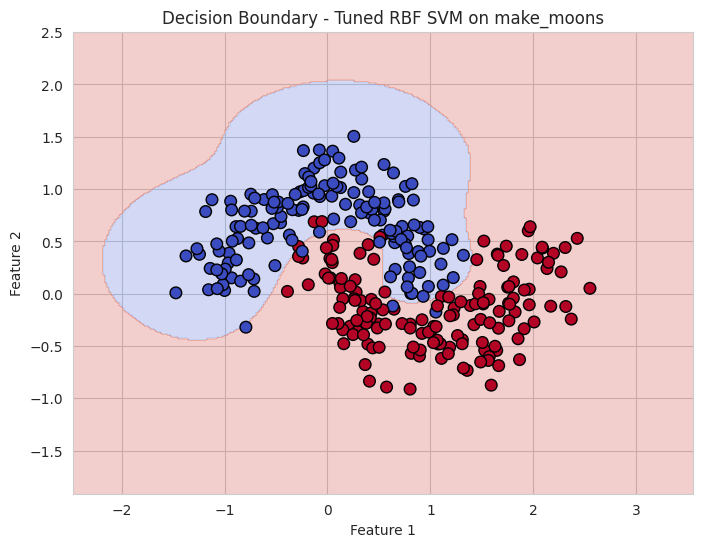

In [31]:
best_moon_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="rbf", C=10, gamma=1))
])

best_moon_model.fit(X_train_m, y_train_m)

plot_decision_boundary(
    best_moon_model,
    X_moons,
    y_moons,
    title="Decision Boundary - Tuned RBF SVM on make_moons"
)

## 21. Ringkasan Hasil Eksperimen

Agar lebih rapi, kita rangkum beberapa hasil model yang sudah dicoba di chapter ini:
- Linear SVM pada Iris
- Linear SVM pada make_moons
- RBF SVM pada make_moons
- Best tuned SVM pada Breast Cancer
- LinearSVC pada high-dimensional data
- RBF SVC pada high-dimensional data

In [32]:
summary_results = pd.DataFrame({
    "Eksperimen": [
        "Linear SVM - Iris (binary)",
        "Linear SVM - make_moons",
        "RBF SVM - make_moons",
        "Best Tuned SVM - Breast Cancer",
        "LinearSVC - High Dimensional",
        "RBF SVC - High Dimensional"
    ],
    "Accuracy/Test Score": [
        round(svm_linear.score(X_test, y_test), 4),
        round(svm_linear_moons.score(X_test_m, y_test_m), 4),
        round(svm_rbf_moons.score(X_test_m, y_test_m), 4),
        round(best_svm.score(X_test_c, y_test_c), 4),
        round(linear_acc, 4),
        round(rbf_acc, 4)
    ]
})

summary_results

,Eksperimen,Accuracy/Test Score
0,Linear SVM - Iris (binary),0.9600
1,Linear SVM - make_moons,0.8533
2,RBF SVM - make_moons,0.9067
3,Best Tuned SVM - Breast Cancer,0.9790
4,LinearSVC - High Dimensional,0.7600
5,RBF SVC - High Dimensional,0.8320


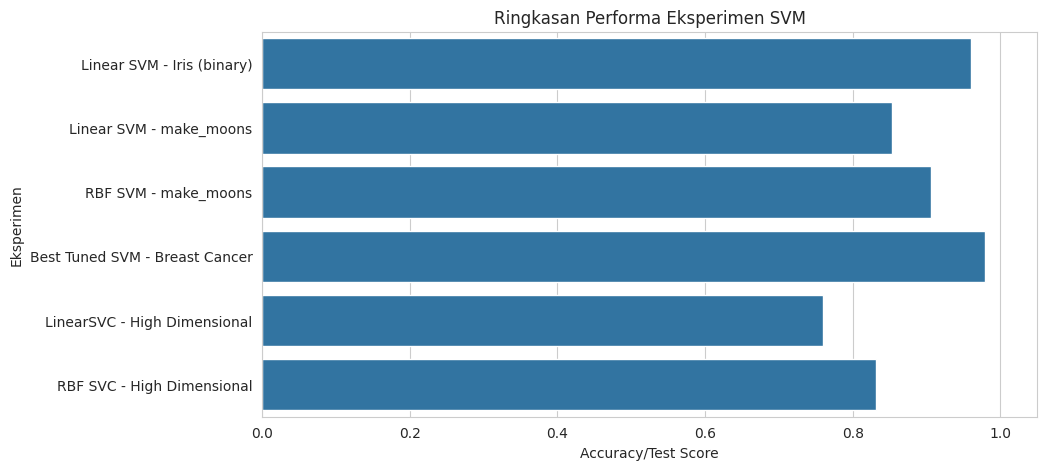

In [33]:
plt.figure(figsize=(10, 5))
sns.barplot(data=summary_results, x="Accuracy/Test Score", y="Eksperimen")
plt.xlim(0, 1.05)
plt.title("Ringkasan Performa Eksperimen SVM")
plt.show()

## 22. Kesimpulan Chapter 7

Beberapa poin penting dari chapter ini:

1. **SVM** adalah algoritma klasifikasi yang bekerja dengan mencari hyperplane terbaik yang memaksimalkan margin.
2. **Support vectors** adalah titik-titik data yang paling berpengaruh dalam menentukan decision boundary.
3. Untuk data yang tidak linear, **kernel trick** sangat penting karena memungkinkan SVM membangun batas keputusan non-linear tanpa harus menghitung transformasi fitur secara eksplisit.
4. Hyperparameter utama SVM yang perlu diperhatikan adalah:
   - **C** → mengatur kekuatan regularisasi / toleransi kesalahan
   - **gamma** → mengatur kompleksitas pengaruh titik pada kernel RBF
5. **GridSearchCV** sangat membantu untuk mencari kombinasi hyperparameter terbaik.
6. Pada data berdimensi tinggi, **LinearSVC** sering lebih efisien, tetapi performanya perlu dibandingkan dengan kernel lain sesuai karakteristik data.
7. Evaluasi model tidak cukup hanya dengan accuracy; kita juga perlu melihat **classification report, confusion matrix, ROC curve, dan cross-validation**.

Secara keseluruhan, chapter ini menunjukkan bahwa SVM adalah salah satu model klasifikasi yang kuat, fleksibel, dan sangat berguna baik untuk data linear maupun non-linear, selama preprocessing dan tuning parameter dilakukan dengan baik.

## 23. Catatan Akhir

Notebook ini merupakan reproduksi pembelajaran Chapter 7 dari buku **scikit-learn Cookbook** dengan penyesuaian agar:
- mudah dijalankan di Google Colab
- hasil visualisasi tampil rapi di GitHub
- teori dan praktik tetap seimbang
- tidak terlalu berat dijalankan, tetapi tetap mencerminkan inti materi chapter

Beberapa contoh pada notebook ini disederhanakan agar fokus pada konsep utama:
- linear vs non-linear SVM
- kernel trick
- tuning hyperparameter
- evaluasi model
- penggunaan SVM pada data berdimensi tinggi